<a href="https://colab.research.google.com/github/tauqeer-jetcom/ML_PROJECTS_1-61023748031/blob/main/titanic_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# step 1
collect the titanic data
    load and understand data

In [33]:
import pandas as pd
import numpy as np

df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# step 2 EDA
check size,columns,missing na values in it.
clean the data, perform EDA.

In [34]:
df.size

10692

In [35]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [37]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [38]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [39]:
df = df.fillna(df['Age'].mean())


In [41]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# step 3 feature engineering

after cleaning data,  split columns if nessary ex:date into year, month week day. seperate categorical and numerical columns one hot encoding.
after thatsplit data into X(feature) and Y(target).


In [46]:
import pandas as pd

# The line df["Sex"].dtype('int32') is incorrect because .dtype is an attribute, not a method.
# To convert categorical features into numerical format for machine learning models,
# we need to use encoding techniques like one-hot encoding.

# First, ensure 'Embarked' missing values are handled correctly before one-hot encoding.
# We will fill missing 'Embarked' values with the most frequent value (mode).
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Perform one-hot encoding for 'Sex' and 'Embarked' columns
# drop_first=True to avoid multicollinearity.
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Define features and target.
# Update the features list to reflect the one-hot encoded columns.
# After one-hot encoding 'Sex', we will have 'Sex_male' (assuming 'female' was dropped first).
# After one-hot encoding 'Embarked', we will have 'Embarked_Q' and 'Embarked_S' (assuming 'C' was dropped first).
features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
target = ['Survived']

X = df[features]
y = df[target]

# step 4 build model classification model

after bulding the model, evaluating performance using metrics

In [50]:
from os import X_OK
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# X and y are already correctly defined and preprocessed by the previous cell (d24Fowu3UQmg).
# Removing the redundant re-definition here to ensure the one-hot encoded X and y are used.

# Correct the assignment of return values from train_test_split.
# It should be X_train, X_test, y_train, y_test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200) # Increased max_iter for convergence for smaller datasets
model.fit(X_train, y_train.values.ravel()) # .values.ravel() to convert y_train to 1D array

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8100558659217877
Precision: 0.7857142857142857
Recall: 0.7432432432432432
F1 Score: 0.7638888888888888


# step 5 visualizing

after improving  performance of the model visualing the model performance.

/tmp/ipykernel_1816/316969107.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


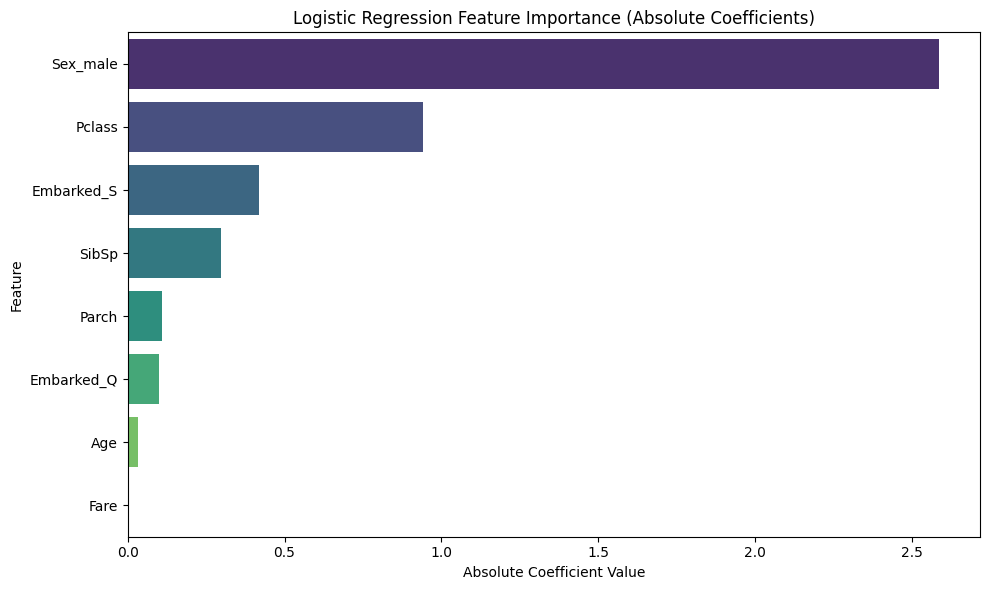

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names from the 'features' list
feature_names = features

# Get the coefficients from the trained Logistic Regression model
# model.coef_ returns a 2D array, so we take the first row (for binary classification)
coefficients = model.coef_[0]

# Create a DataFrame for easier plotting
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(coefficients) # Use absolute values for importance
}).sort_values(by='Importance', ascending=False)

# Create the bar plot
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Logistic Regression Feature Importance (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [57]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'ModelOptimization'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary", "ModelVisualization"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig)


The bar chart above visualizes the importance of each feature in the Logistic Regression model. Features with larger absolute coefficient values are considered more influential in predicting the target variable ('Survived').

/tmp/ipykernel_1816/1276265208.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Actual_Survived', data=predictions_df, ax=axes[0], palette='viridis')
/tmp/ipykernel_1816/1276265208.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Predicted_Survived', data=predictions_df, ax=axes[1], palette='viridis')


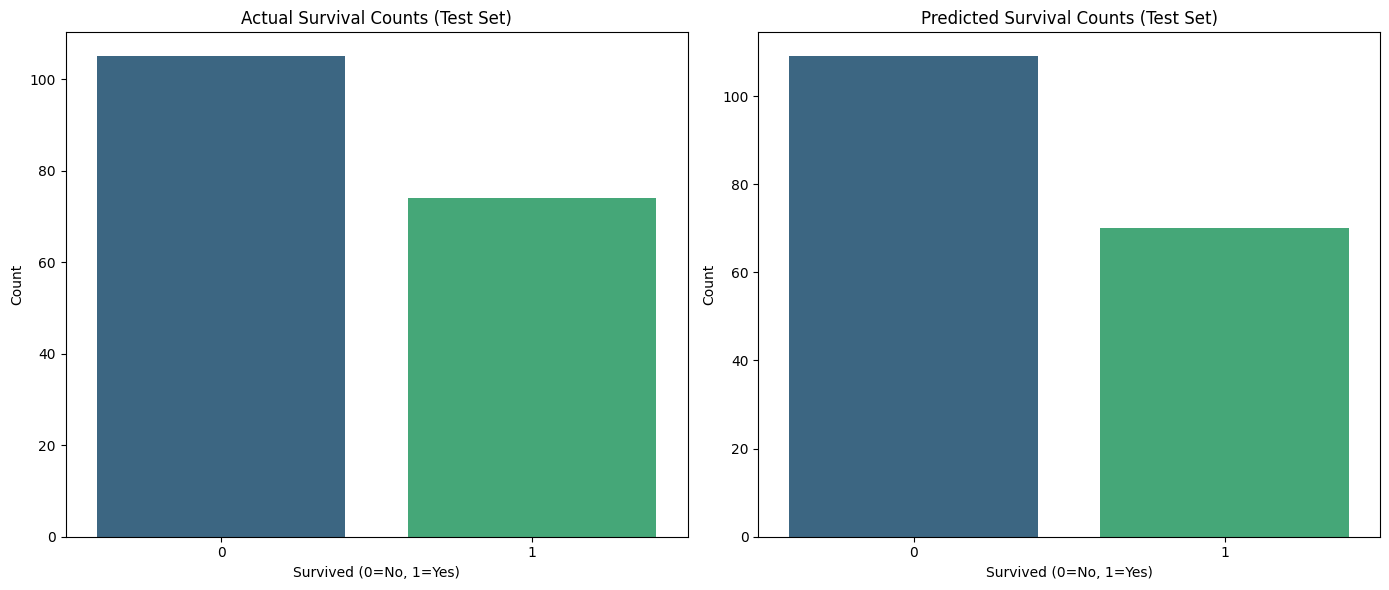

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine X_test, y_test, and y_pred_tuned into a single DataFrame for plotting
# Reset index of y_test to align it correctly with X_test and y_pred_tuned
y_test_reset = y_test.reset_index(drop=True)

predictions_df = pd.DataFrame(X_test).reset_index(drop=True)
predictions_df['Actual_Survived'] = y_test_reset
predictions_df['Predicted_Survived'] = y_pred

# Create a figure with two subplots for actual vs predicted survival counts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(x='Actual_Survived', data=predictions_df, ax=axes[0], palette='viridis')
axes[0].set_title('Actual Survival Counts (Test Set)')
axes[0].set_xlabel('Survived (0=No, 1=Yes)')
axes[0].set_ylabel('Count')

sns.countplot(x='Predicted_Survived', data=predictions_df, ax=axes[1], palette='viridis')
axes[1].set_title('Predicted Survival Counts (Test Set)')
axes[1].set_xlabel('Survived (0=No, 1=Yes)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


In [59]:
# @title step_artifacts
num_fig = "2" # @param {type:"string"}
step = 'ModelVisualization'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary", "ModelVisualization"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig)


The plots above show the distribution of actual survival outcomes versus the model's predicted survival outcomes for the test set. This visual comparison helps in understanding how well the model's predictions align with the true labels.